EDA NOTEBOOK 

### 0. Dataset Dimensions and Structure

After loading and merging the separate red and white wine files to maximize the sample size, I verified the DataFrame's structural properties and overall completeness. 

#### Comments:

- The combined dataset consists of 6,497 rows and 13 columns
- Every column contains exactly 6,497 non null entries. This means that the dataset is completely intact with zero missing values. Thus, I doon't need to implement any missing data imputation techniques during the preprocessing stage

- Numeric Predictors: 11 continuous variables containing the physical and chemical properties of the wine (all correctly formatted as float64)
- Target Variable: quality is stored as an integer (int64)
- type is a categorical variable (object) that I manually generated to retain whether a sample originated from the red or white wine subset

In [ ]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# dataset (red wines)
df_red = pd.read_csv("C:/Users/ryanf/Desktop/Final Project (pstat131)/Dataset/winequality-red.csv")
df_red['type'] = 'red'

# dataset (white wines) 
# noting it is semicolon delimited
df_white = pd.read_csv("C:/Users/ryanf/Desktop/Final Project (pstat131)/Dataset/winequality-white.csv", sep=';')
df_white['type'] = 'white'

# combining datasets
df = pd.concat([df_red, df_white], ignore_index=True)

# verification for loading my dataset + combination
print(f"Total dataset shape: {df.shape}")
print(df.info())

Total dataset shape: (6497, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None


### 1. Distribution of the Target Variable: Wine Quality

In order to understand the behavior of the response variable, quality, I visualized its distribution across both red and white wine variants.

#### Comments:
- The wine quality scores are not evenly distributed as the majority of observations are heavily clustered around average ratings of 5 and 6. Extreme scores such as a low 3 or an 8 or 9 are sparse
- By combining the datasets to get a larger sample size (~6,500 total observations), white wine samples outnumber red wine samples (~4,900 white vs. ~1,600 red). This distribution remains consistent across both categories
- As noted in my data memo and its respective feedback, this level of concentration is acceptable for a regression framework. However, it means the models will naturally have far more data to learn the physicochemical profiles of "average" wines. Thus, I would expect higher prediction errors (larger residuals) on the tail ends of the distribution (scores of 3, 4, 8, and 9) due to the scarcity of these training observations.To ensure the models are evaluated fairly across this distribution, I'm going to use stratified splitting based on the quality score when building the training and testing parts

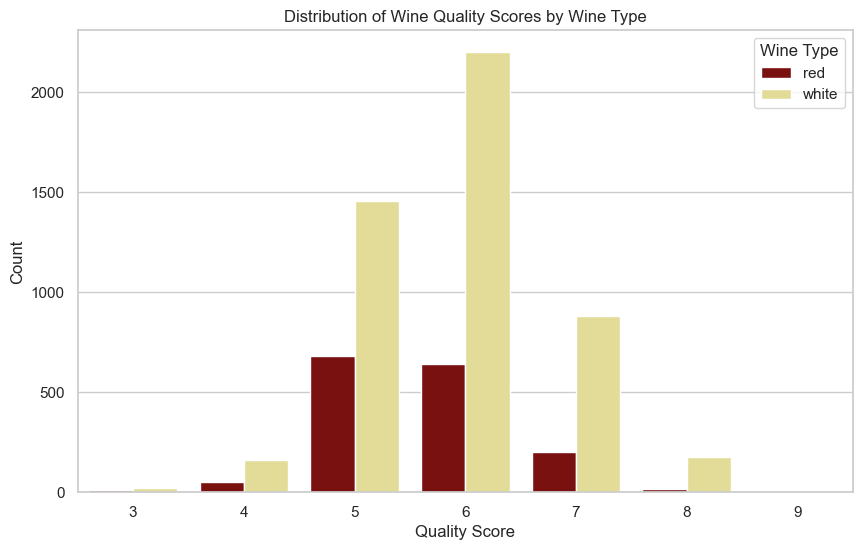

In [32]:
# distribution of wine quality
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='quality', hue='type', palette={'red': '#8b0000', 'white': '#f0e68c'})
plt.title('Distribution of Wine Quality Scores by Wine Type')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.legend(title='Wine Type')
plt.show()

### 2. Correlation Analysis: Physicochemical Properties

In order to explor and identify potential multicollinearity among the predictors and assess linear relationships with the target variable, I made a correlation heatmap of all the continuous numeric features.

#### Comments:

- Several predictor variables show moderate to strong correlations with one another. Most notably, total sulfur dioxide and free sulfur dioxide have a strong positive correlation (0.72). Also, density has a strong negative correlation with alcohol (-0.69) and a moderate positive correlation with residual sugar (0.55)
- When looking at the bottom row (correlations with quality), alcohol has the strongest positive linear relationship (0.44). volatile acidity (-0.27) and density (-0.31) have the strongest negative relationships. This aligns with my initial domain knowledge hypothesis that alcohol and volatile acidity are key drivers of perceived wine quality
- The highly correlated predictor pairs (like the sulfur dioxides and density/alcohol) confirms that standard Ordinary Least Squares (OLS) regression might suffer from inflated variance due to multicollinearity. Thus, this is a reason to use Elastic Net Regression as the baseline parametric model. The penalty terms in Elastic Net (combining Ridge and Lasso) will manage these correlated features by either shrinking their coefficients together or dropping redundant predictors entirely.

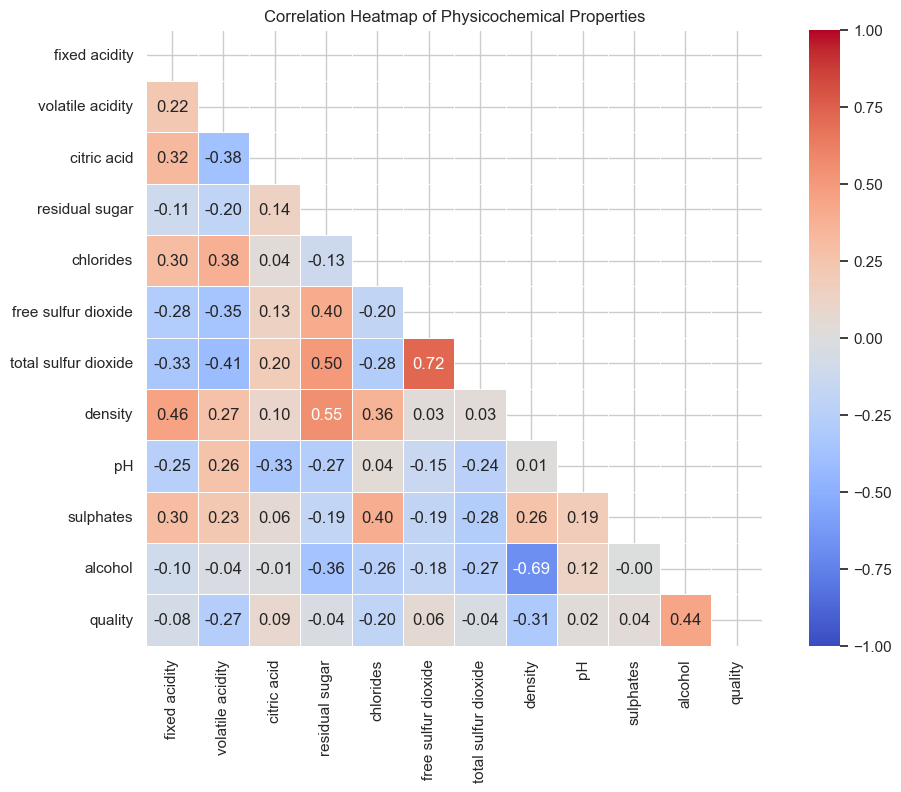

In [33]:
# correlation heatmap (numeric features only)
plt.figure(figsize=(12, 8))
# noting dropping the categorical 'type' column for the correlation matrix
corr_matrix = df.drop('type', axis=1).corr()

# mask to hide the upper triangle to make it look cleaner
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Correlation Heatmap of Physicochemical Properties')
plt.show()

### 3. Key Predictors vs. Wine Quality

In order to test my initial domainknowledge hypotheses, I have visualized the relationship between the target variable (quality) and two of the most heavily correlated predictors (alcohol and volatile acidity).

#### Comments:

- There's a distinct upward trend between alcohol content and wine quality for both red and white variants. Wines that scored a 7, 8, or 9 consistently exhibit higher median alcohol percentages than those scoring in the 3 to 5 range
- Volatile acidity, which relates to the amount of acetic acid that can create a commonly undesirable vinegar like taste, shows a negative relationship with quality. As the quality score increases, the median volatile acidity decreases 
- The boxplots show that red wines naturally contain higher levels of volatile acidity across all quality tiers compared to white wines. 
- These visualizations confirm that alcohol and volatile acidity will be highly influential features for the predictive models. Because the trends appear relatively linear (monotonically increasing/decreasing), parametric models like the Elastic Net should capture these main effects reasonably well. The presence of numerous outliers suggests that while these two variables are strong predictors, they do not tell the whole story. This partly justifies the need to include the remaining features and test more complex and non linear models like Random Forest and others to capture interactions.

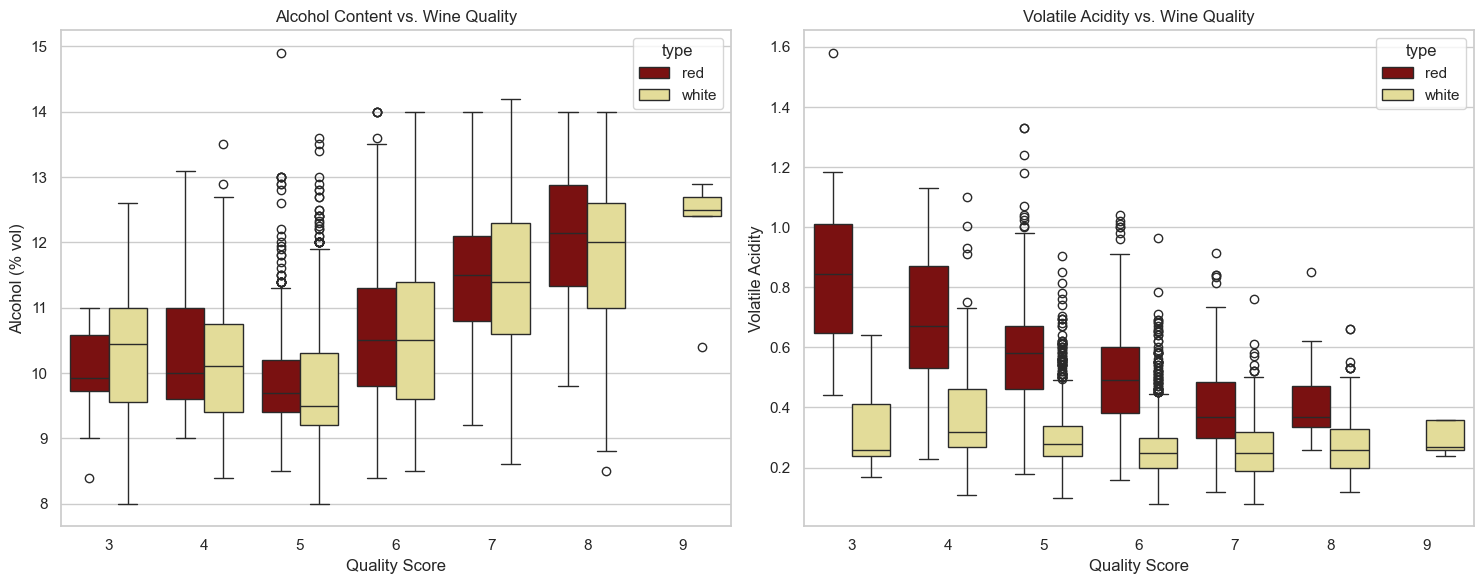

In [34]:
# key predictors vs quality
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1: alcohol vs quality
sns.boxplot(ax=axes[0], data=df, x='quality', y='alcohol', hue='type', palette={'red': '#8b0000', 'white': '#f0e68c'})
axes[0].set_title('Alcohol Content vs. Wine Quality')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Alcohol (% vol)')

# 2: volatile acidity vs quality
sns.boxplot(ax=axes[1], data=df, x='quality', y='volatile acidity', hue='type', palette={'red': '#8b0000', 'white': '#f0e68c'})
axes[1].set_title('Volatile Acidity vs. Wine Quality')
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Volatile Acidity')

plt.tight_layout()
plt.show()

### 4. Summary Statistics and Feature Scaling

To understand the baseline numerical landscape of the dataset, I generated a statistics table for all continuous predictors.

#### Comments:

- The measurements in this dataset operate on different numerical scales. For example, chlorides are measured in minute fractions (mean ~0.056) while total sulfur dioxide is measured in the hundreds (mean ~115.7, max 440). 
- Several variables show maximum values that sit far above their 75th percentiles. residual sugar goes from 8.1 at the 75th percentile up to an extreme max of 65.8. free sulfur dioxide similarly jumps from 41 to 289
- This table shows that centering and scaling (standardization) is a mandatory preprocessing step needed for this dataset. Distance based algorithms (like K-Nearest Neighbors) and penalized regression models (like Elastic Net baseline) are highly sensitive to unscaled data. If fitting an Elastic Net on this raw data, the shrinkage penalty would possibly unfairly target the variables measured in larger units (like total sulfur dioxide) because their numerical magnitude is larger and not necessarily because they are stronger predictors of quality.

In [35]:
# summary statistics
# noting dropping the categorical 'type' column for the summary
summary_stats = df.drop('type', axis=1).describe().T
print(summary_stats)

                       count        mean        std      min       25%  \
fixed acidity         6497.0    7.215307   1.296434  3.80000   6.40000   
volatile acidity      6497.0    0.339666   0.164636  0.08000   0.23000   
citric acid           6497.0    0.318633   0.145318  0.00000   0.25000   
residual sugar        6497.0    5.443235   4.757804  0.60000   1.80000   
chlorides             6497.0    0.056034   0.035034  0.00900   0.03800   
free sulfur dioxide   6497.0   30.525319  17.749400  1.00000  17.00000   
total sulfur dioxide  6497.0  115.744574  56.521855  6.00000  77.00000   
density               6497.0    0.994697   0.002999  0.98711   0.99234   
pH                    6497.0    3.218501   0.160787  2.72000   3.11000   
sulphates             6497.0    0.531268   0.148806  0.22000   0.43000   
alcohol               6497.0   10.491801   1.192712  8.00000   9.50000   
quality               6497.0    5.818378   0.873255  3.00000   5.00000   

                            50%      

### 5. Distributions of Continuous Predictors

In order to identify variables that might require transformation before modeling, I plotted the histograms of all 11 continuous physicochemical features.

#### Comments:

- Several variables show heavy right skewness with long and sparse tails. residual sugar and chlorides are the most prominent examples with the majority of observations concentrated near zero but a few extreme outliers stretching far out on the x-axis. free sulfur dioxide and sulphates also display rightward skews
- pH and density show relatively symmetric, bell shaped distributions that closely approximate normality.
- citric acid is has a massive spike at exactly 0.0 which suggesting a large number of wines in our dataset have no measurable citric acid
- The skewness in features like residual sugar and chlorides will negatively impact parametric linear models (like Elastic Net) since these models generally assume normally distributed errors and are sensitive to extreme outliers pulling the regression line. During preprocessing, I'll explore applying mathematical transformations specifically (logarithmic transformations) to these skewed variables. This should compress the extreme tails and bring the distributions closer to normality. It should also improve the stability and performance of the baseline linear model.

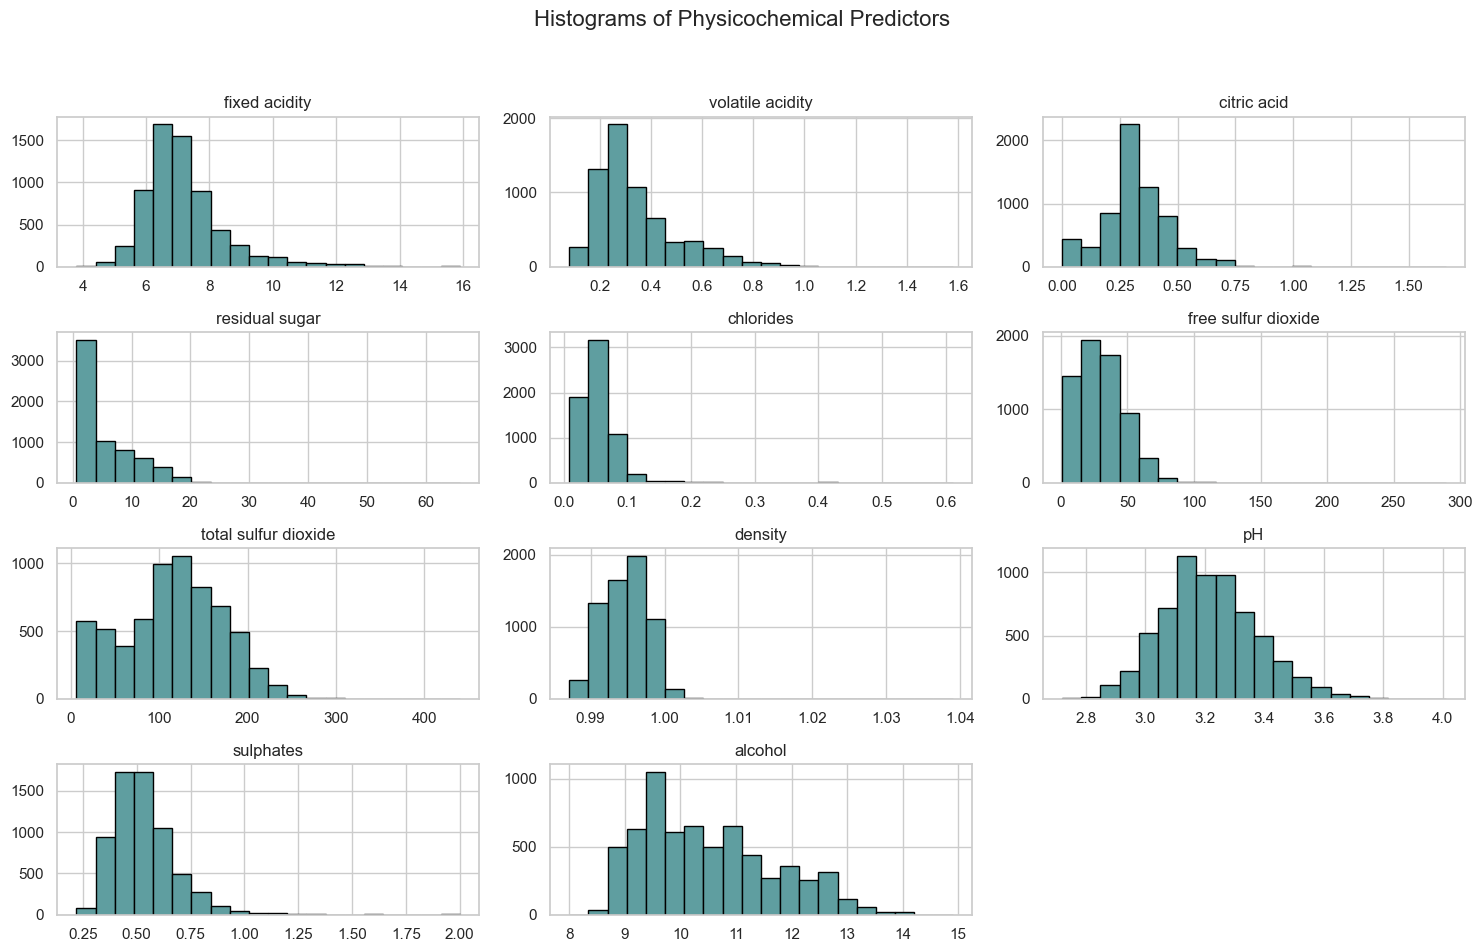

In [36]:
# distributions of continuous predictors
# looking at the numeric columns and  the target 'quality'
features = df.drop(['quality', 'type'], axis=1)

features.hist(bins=20, figsize=(15, 10), color='#5f9ea0', edgecolor='black')
plt.suptitle('Histograms of Physicochemical Predictors', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 6. Saving and Exporting

#### Comments:

- The combined red and white dataset is exported as a single CSV file to be loaded in, read, and used by the next steps and notebooks in this project

In [37]:
base_dir = "C:/Users/ryanf/Desktop/PSTAT 131/Final/Final Project (pstat131)/"

# filename for the combined dataset
output_filename = "winequality-combined.csv"
output_path = os.path.join(base_dir, output_filename)

# exporting the dataframe to CSV
df.to_csv(output_path, index=False)

# verification this worked
print(f"Step completed. The combined dataset is saved to:\n{output_path}")

Step completed. The combined dataset is saved to:
C:/Users/ryanf/Desktop/PSTAT 131/Final/Final Project (pstat131)/winequality-combined.csv
